In [8]:
# input
pred_file = "../../data/pred.tsv"
anno_file = "../../../collect_mbp/data/metal_chains.tsv"
cluster_file = "../../data/result_cluster.tsv"
# output
fig_file = "./fig/eval_result.pdf"

In [9]:
import pandas as pd

In [10]:
df_pred = pd.read_table(pred_file)
df_anno = pd.read_table(anno_file)

pred_resi = set()
for _, row in df_pred.iterrows():
    for i in row['posi'].split(','):
        pred_resi.add((row['seq_id'], int(i)))

df_anno = df_anno[df_anno['resi'].map(lambda x: x in {"C", "H", "E", "D"})]
anno_resi = set()
for pdb_chain, df_chain in df_anno.groupby(by=["pdb", "metal_chain"]):
    pdb, chain = pdb_chain
    seq_id = f"{pdb}_{chain}"
    for i in df_chain["resi_ndb_seq_can_num"]:
        anno_resi.add((seq_id, int(i) - 1))
inter = pred_resi & anno_resi
len(inter)
len(pred_resi)
len(anno_resi)
prec = len(inter) / len(pred_resi)
recall = len(inter) / len(anno_resi)
f1 = 2 * prec * recall / (prec + recall)
print(prec, recall, f1)

3049

3576

3499

0.8526286353467561 0.8713918262360675 0.8619081272084805


In [11]:
df_cluster = pd.read_table(cluster_file, sep="\s+", header=None, names=["repr", "member"])

cur = set(zip(df_anno['pdb'], df_anno['metal_chain']))
cur = set([f"{i[0]}_{i[1]}" for i in cur])
novels = set()
for (repr,), df_repr in df_cluster.groupby(by=["repr"]):
    members = set(df_repr['member'])
    uniq = members - (members & cur)
    if len(uniq) == 0:
        novels |= members
len(cur)
len(novels)

723

354

In [12]:
pred_resi = set([i for i in pred_resi if i[0] in novels])
anno_resi = set([i for i in anno_resi if i[0] in novels])
inter = pred_resi & anno_resi
len(inter)
len(pred_resi)
len(anno_resi)
prec = len(inter) / len(pred_resi)
recall = len(inter) / len(anno_resi)
f1 = 2 * prec * recall / (prec + recall)
print(prec, recall, f1)

1354

1648

1681

0.8216019417475728 0.8054729327781083 0.8134574947431662


<Figure size 240x240 with 0 Axes>

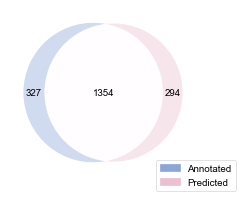

In [13]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
colors = ["#8CA6D9", "#EDBFD1"]

plt.style.use(f"{PROJECT_DIR}/asset/metalnet.mplstyle")
plt.figure(figsize=(2.4, 2.4))

venn2([anno_resi, pred_resi], set_colors=colors, set_labels=None)
legend_patches = [
    Patch(color=colors[0], label="Annotated"),
    Patch(color=colors[1], label="Predicted")
]

plt.legend(handles=legend_patches, loc="center", bbox_to_anchor=(1, 0))
plt.savefig(fig_file, bbox_inches='tight', transparent=True)